In [1]:
%load_ext autoreload
%autoreload 2

from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF, CFT
from trees.brute_force import BruteForce
from trees.helpers import visualize_recommendations, visualize_recommendations2

N = 10000
K = 5
W = 0.5
MIN_S = 0.3
MAX_S = 0.95
SEED = 42
OVERLAP_MEASURE = "overlap_coefficient"

scores = pd.DataFrame()

data = Data()
data.generate(n=N, seed=SEED)
data.generate_random_condition(min_s=MIN_S, max_s=MAX_S)
data.set_overlap_measure(overlap_measure=OVERLAP_MEASURE)


cf = CF(data)
algorithms = [CT(data, on="D"), CT(data, on="P"), cf, CFT(cf), BruteForce(cf) ]
for alg in algorithms:
    alg.fit()
    alg.scan()
    score = data.get_topK(alg, k=K, w=W)
    scores=pd.concat([scores, score], ignore_index=True)

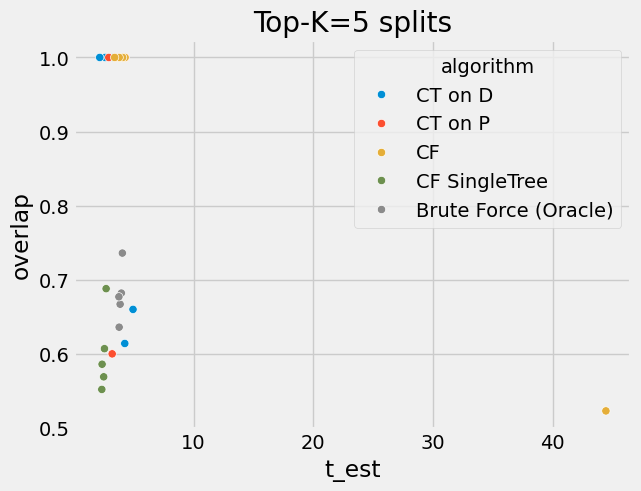

In [2]:
sns.scatterplot(data=scores, x="t_est", y="overlap", hue="algorithm")
plt.title("Top-K=5 splits")
plt.show()

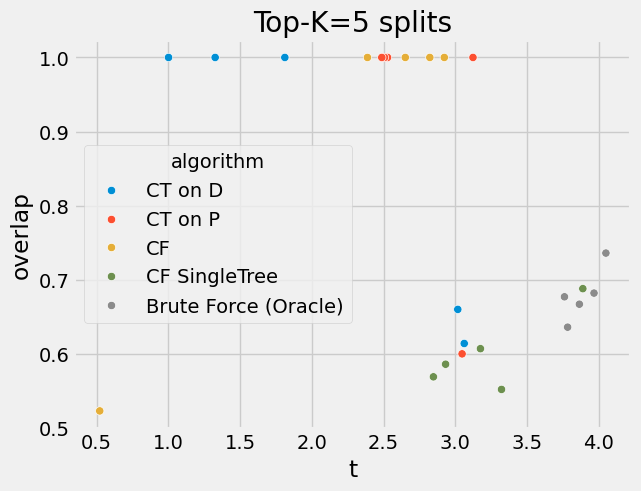

In [3]:
sns.scatterplot(data=scores, x="t", y="overlap", hue="algorithm")
plt.title("Top-K=5 splits")
plt.show()

In [4]:
k_all = 20
all_scores = pd.DataFrame()
for alg in algorithms:
    score = data.get_topK(alg, k=k_all, w=W)
    all_scores=pd.concat([all_scores, score], ignore_index=True)

for alg in algorithms:
    print(alg.algorithm, ":", all_scores[all_scores["algorithm"]==alg.algorithm].shape[0], 'splits')

CT on D : 20 splits
CT on P : 20 splits
CF : 20 splits
CF SingleTree : 20 splits
Brute Force (Oracle) : 20 splits


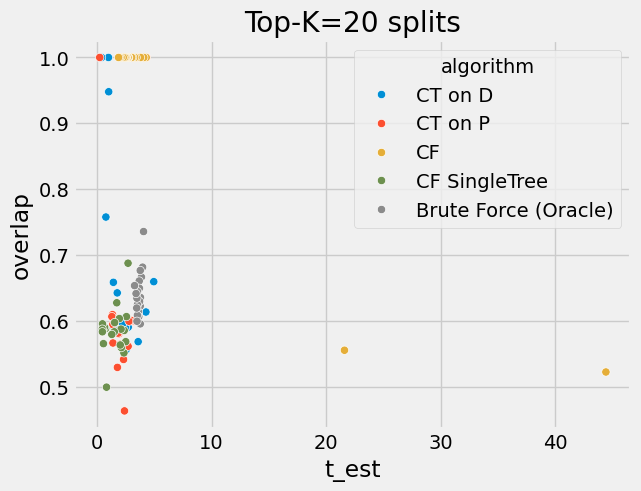

In [5]:
sns.scatterplot(data=all_scores, x="t_est", y="overlap", hue="algorithm")
plt.title(f"Top-K={k_all} splits")
plt.show()

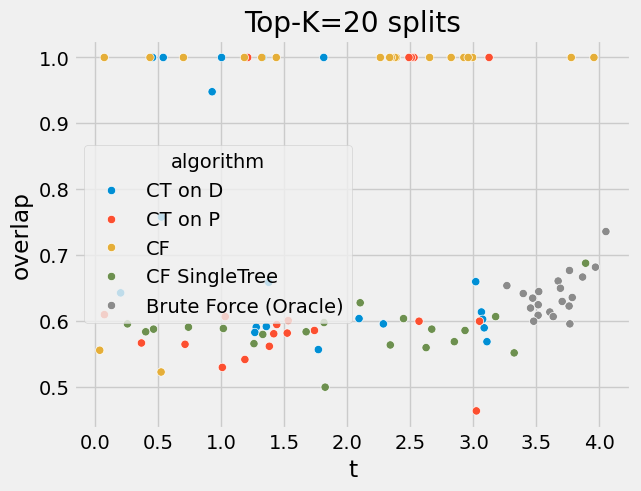

In [17]:
sns.scatterplot(data=all_scores, x="t", y="overlap", hue="algorithm")
plt.title(f"Top-K={k_all} splits")
plt.show()

Text(0.5, 1.0, "User's P: feature_6 > -0.20284697064188606")

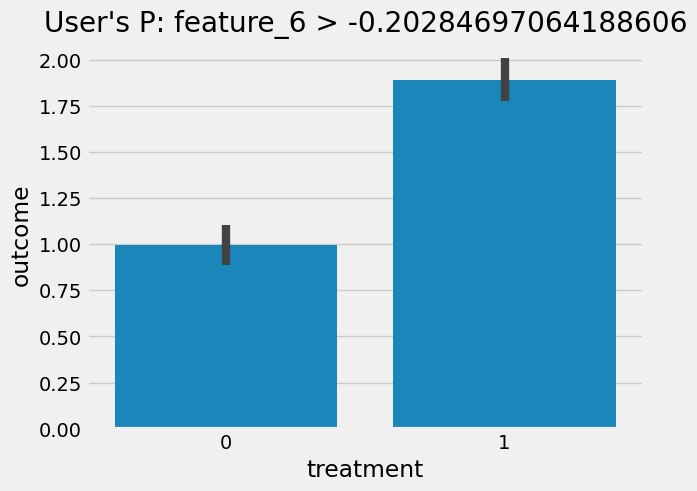

In [7]:
# visualize the user's query data.q_df where T0=1 and T1=0

# create a barplot grouping T for data.q_df
sns.barplot(x='treatment', y='outcome', data=data.q_df)
plt.title("User's P: "+ data.p)

In [8]:
import polars as pl
# in the polars dataframe q_df compute the average treatment effect
t1_data = data.q_df.filter(pl.col("treatment") == 1).select(pl.col("outcome")).mean().item()
t0_data = data.q_df.filter(pl.col("treatment") == 0).select(pl.col("outcome")).mean().item()
ate = t1_data - t0_data

print("---- ATE FROM THE DATA ----")
print("ATE:", round(ate,3))
# print("T1:", round(t1_data,2), "T0:", round(t0_data,2))


print("---- GROUND TRUTH ATE ----")
print("ATE:", round(data.q_df.select(pl.col("ITE").mean()).item(),3))



print("---- ATE FROM CF ----")
X_subpopulation = data.q_df.select(pl.exclude(["treatment", "outcome", "ITE", "id"]))

# Compute the CATE for the subpopulation
ate = cf.forest.effect(X_subpopulation).mean()
print("ATE:", round(ate,3)) # why should this be accurate? feature_2 is not even in the tree 


---- ATE FROM THE DATA ----
ATE: 0.895
---- GROUND TRUTH ATE ----
ATE: 0.815
---- ATE FROM CF ----
ATE: 0.84


# Recommendations from CT on D

In [9]:
top_ct_d = scores[(scores['algorithm']=='CT on D')]
top_ct_d

,condition,t_est,overlap,T0,T1,depth,rows,selectivity,selectivity_to_P_ratio,norm_cate,score,t,features,overlap_between_K,coverage,true_score,algorithm,execution_time
0,feature_0 > -1.656 AND feature_0 > -0.41 AND f...,3.291,1.000,0.77,4.06,6,108,0.0108,0.018493,0.67,0.83,1.812,3.0,0.56057,0.0472,0.64,CT on D,0.03
1,feature_0 > -1.656 AND feature_0 > -0.41 AND f...,4.942,0.660,0.84,5.78,6,100,0.0100,0.017123,1.00,0.83,3.018,3.0,0.56057,0.0472,0.56,CT on D,0.03
2,feature_0 > -1.656 AND feature_0 > -0.41 AND f...,2.614,1.000,0.46,3.08,5,270,0.0270,0.046233,0.53,0.76,1.326,3.0,0.56057,0.0472,0.60,CT on D,0.03
3,feature_0 > -1.656 AND feature_0 > -0.41 AND f...,4.254,0.614,0.80,5.06,5,202,0.0202,0.034589,0.86,0.74,3.063,2.0,0.56057,0.0472,0.54,CT on D,0.03
4,feature_0 > -1.656 AND feature_0 > -0.41 AND f...,2.162,1.000,0.26,2.42,6,162,0.0162,0.027740,0.44,0.72,1.001,3.0,0.56057,0.0472,0.58,CT on D,0.03


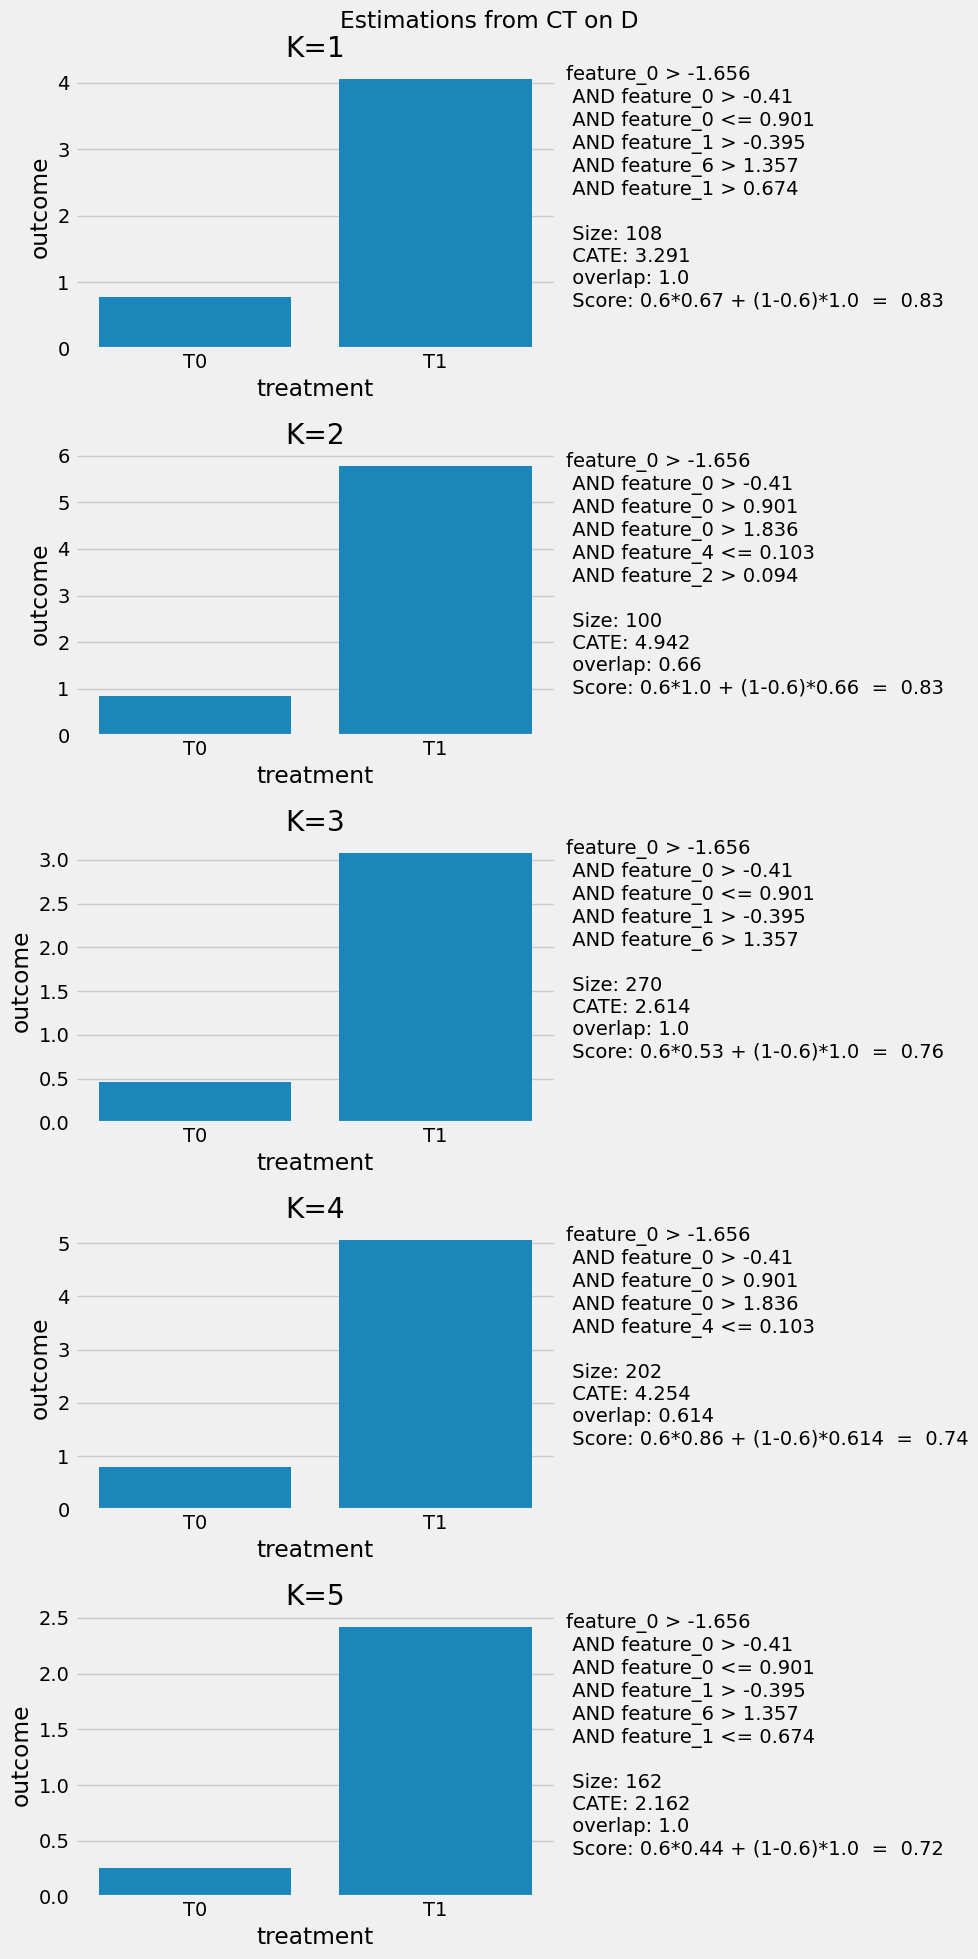

In [18]:
visualize_recommendations(top_ct_d)

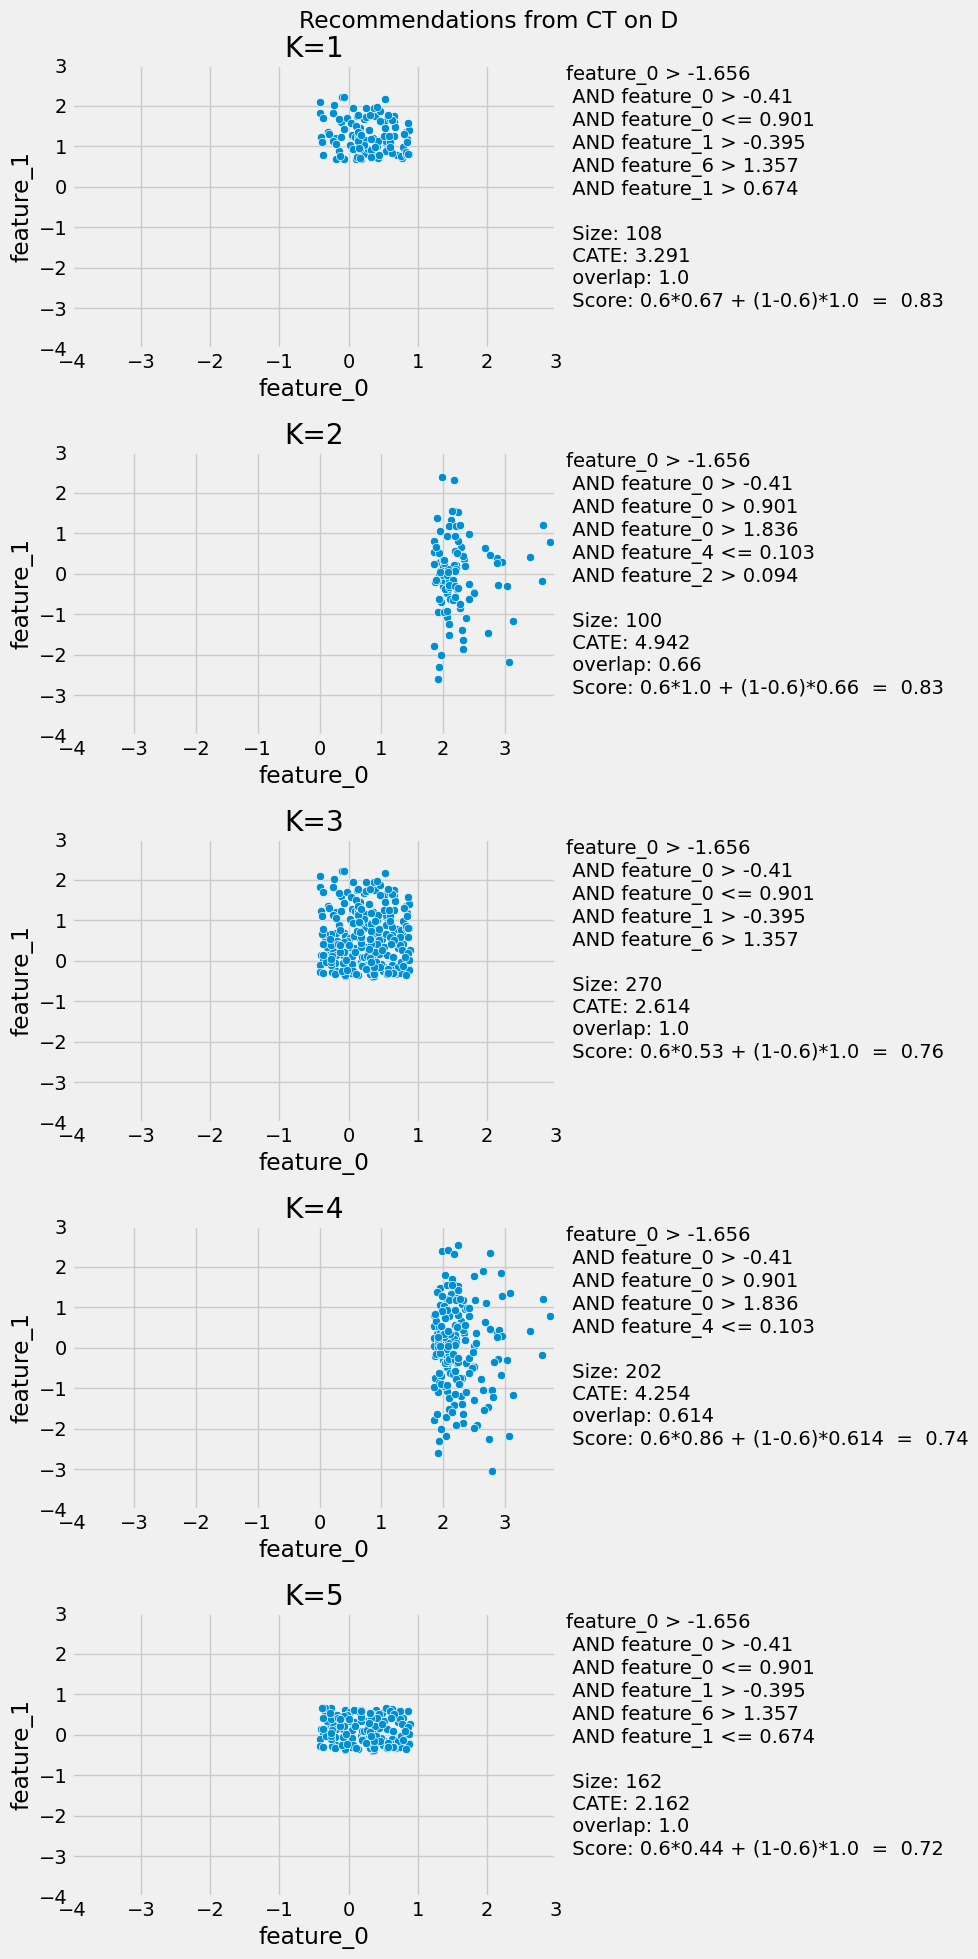

In [19]:
visualize_recommendations2(top_ct_d)

# Recommendations from CT on P

In [11]:
top_ct_p = scores[(scores['algorithm']=='CT on P')]
top_ct_p

,condition,t_est,overlap,T0,T1,depth,rows,selectivity,selectivity_to_P_ratio,norm_cate,score,t,features,overlap_between_K,coverage,true_score,algorithm,execution_time
5,feature_0 > 0.172 AND feature_0 > 1.804 AND fe...,4.311,1.0,0.73,5.05,3,100,0.0100,0.017123,1.00,1.00,3.124,2.0,0.657754,0.0615,0.74,CT on P,0.06
6,feature_0 > 0.172 AND feature_0 <= 1.804 AND f...,4.188,1.0,1.10,5.29,5,104,0.0104,0.017808,0.97,0.99,2.528,4.0,0.657754,0.0615,0.69,CT on P,0.06
7,feature_0 > 0.172 AND feature_0 <= 1.804 AND f...,3.520,1.0,1.33,4.85,4,220,0.0220,0.037671,0.82,0.91,2.507,3.0,0.657754,0.0615,0.69,CT on P,0.06
8,feature_0 > 0.172 AND feature_0 <= 1.804 AND f...,2.921,1.0,1.54,4.46,5,116,0.0116,0.019863,0.68,0.84,2.488,4.0,0.657754,0.0615,0.69,CT on P,0.06
9,feature_0 > 0.172 AND feature_0 > 1.804,3.201,0.6,1.71,4.91,2,395,0.0395,0.067637,0.74,0.67,3.048,1.0,0.657754,0.0615,0.53,CT on P,0.06


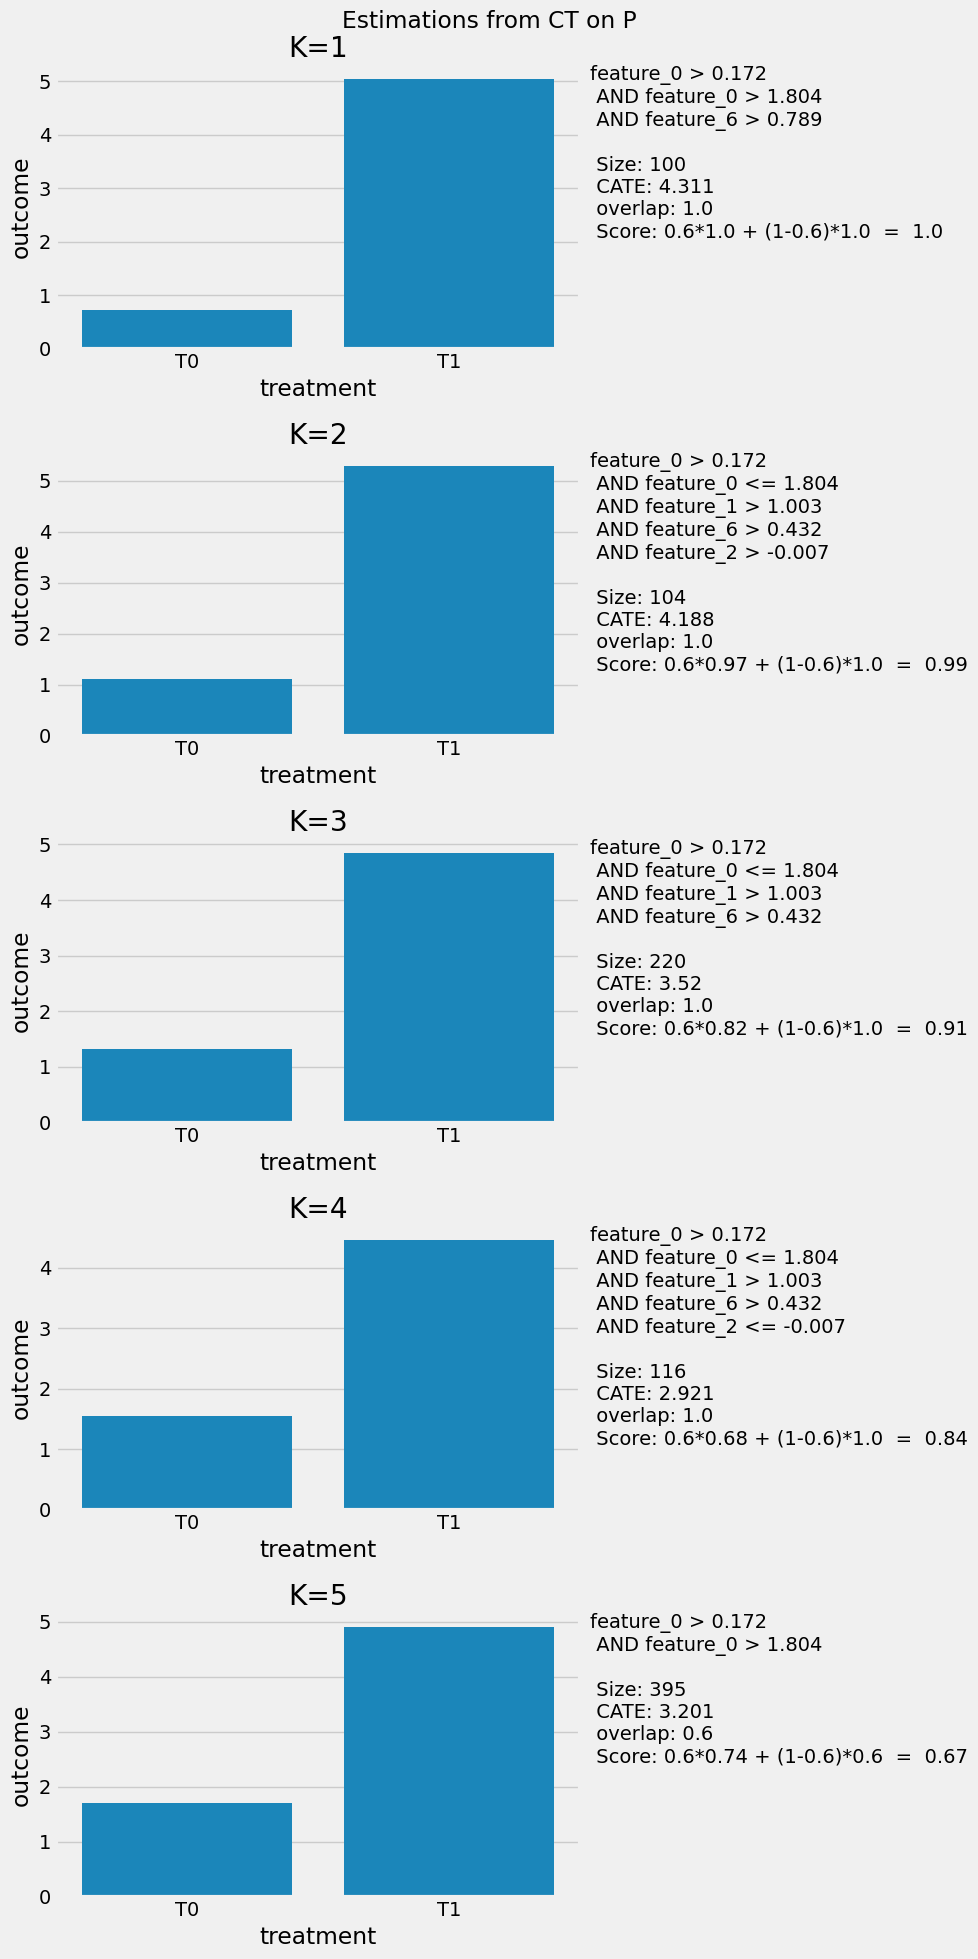

In [12]:
visualize_recommendations(top_ct_p)

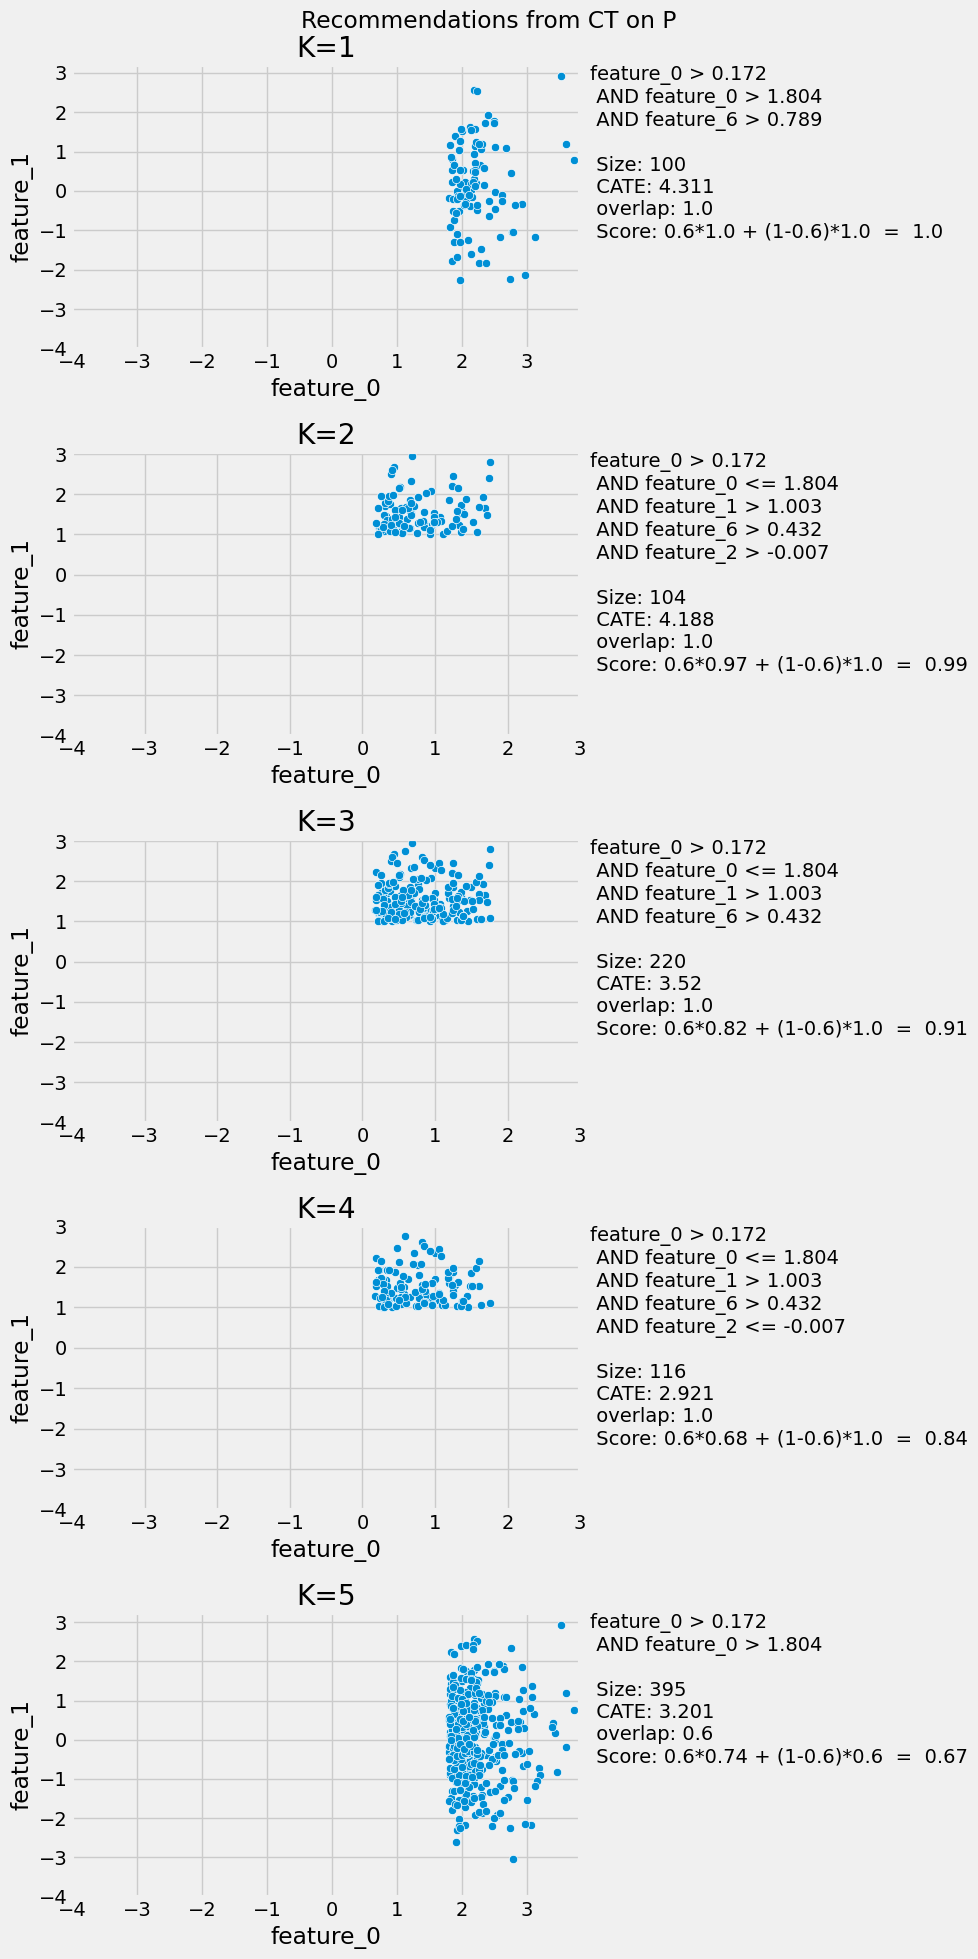

In [20]:
visualize_recommendations2(top_ct_p)

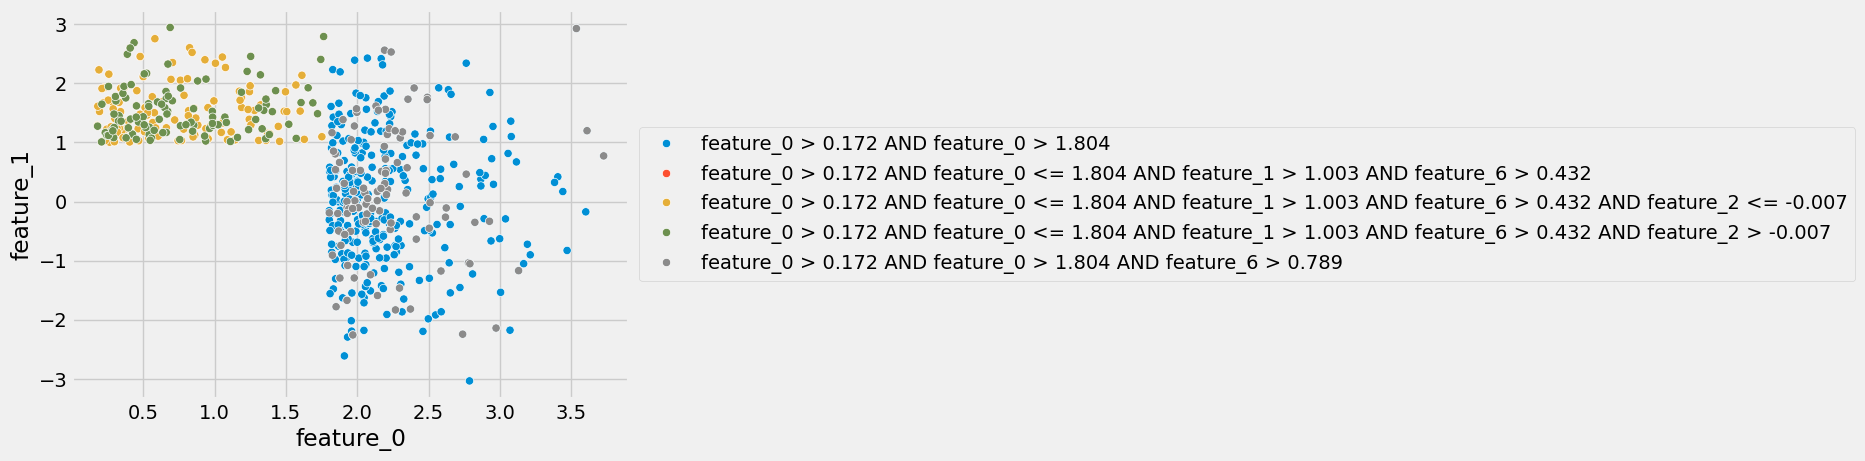

In [13]:
# create a single plot with the 5 classes based on each recommendation
import polars as pl

df_plot = pd.DataFrame(columns=['feature_0', 'feature_1', 'condition'])
for i in [4,2, 3,1,0]:
    condition = top_ct_p.iloc[i]['condition']
    dt = data.execute(condition)
    dt = dt[['feature_0', 'feature_1']]

    dt = pd.DataFrame(dt, columns=['feature_0', 'feature_1'])
    dt['condition'] = condition

    df_plot = pd.concat([df_plot, dt], ignore_index=True)
    
sns.scatterplot(x='feature_0', y='feature_1', hue='condition', data=df_plot)
# reduce legend size
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

# Visualizations from the CF

In [14]:
top_cf = scores[(scores['algorithm']=='CF')]
top_cf

,condition,t_est,overlap,T0,T1,depth,rows,selectivity,selectivity_to_P_ratio,norm_cate,score,t,features,overlap_between_K,coverage,true_score,algorithm,execution_time
10,feature_0 <= 0.038 AND feature_1 <= -0.611 AND...,44.431,0.523,NaN,NaN,4,44,0.0044,0.007534,1.00,0.76,0.521,4.0,0.782443,0.041,0.30,CF,0.94
11,feature_0 > 0.065 AND feature_1 <= 1.168 AND f...,4.280,1.000,NaN,NaN,4,51,0.0051,0.008733,0.10,0.55,2.823,3.0,0.782443,0.041,0.72,CF,0.94
12,feature_0 > 0.071 AND feature_1 > 1.192 AND fe...,4.071,1.000,NaN,NaN,4,62,0.0062,0.010616,0.09,0.55,2.652,3.0,0.782443,0.041,0.70,CF,0.94
13,feature_0 > -0.509 AND feature_0 > 1.587 AND f...,3.785,1.000,NaN,NaN,4,197,0.0197,0.033733,0.09,0.54,2.924,3.0,0.782443,0.041,0.72,CF,0.94
14,feature_0 > 0.043 AND feature_1 > 0.641 AND fe...,3.407,1.000,NaN,NaN,4,170,0.0170,0.029110,0.08,0.54,2.388,4.0,0.782443,0.041,0.68,CF,0.94


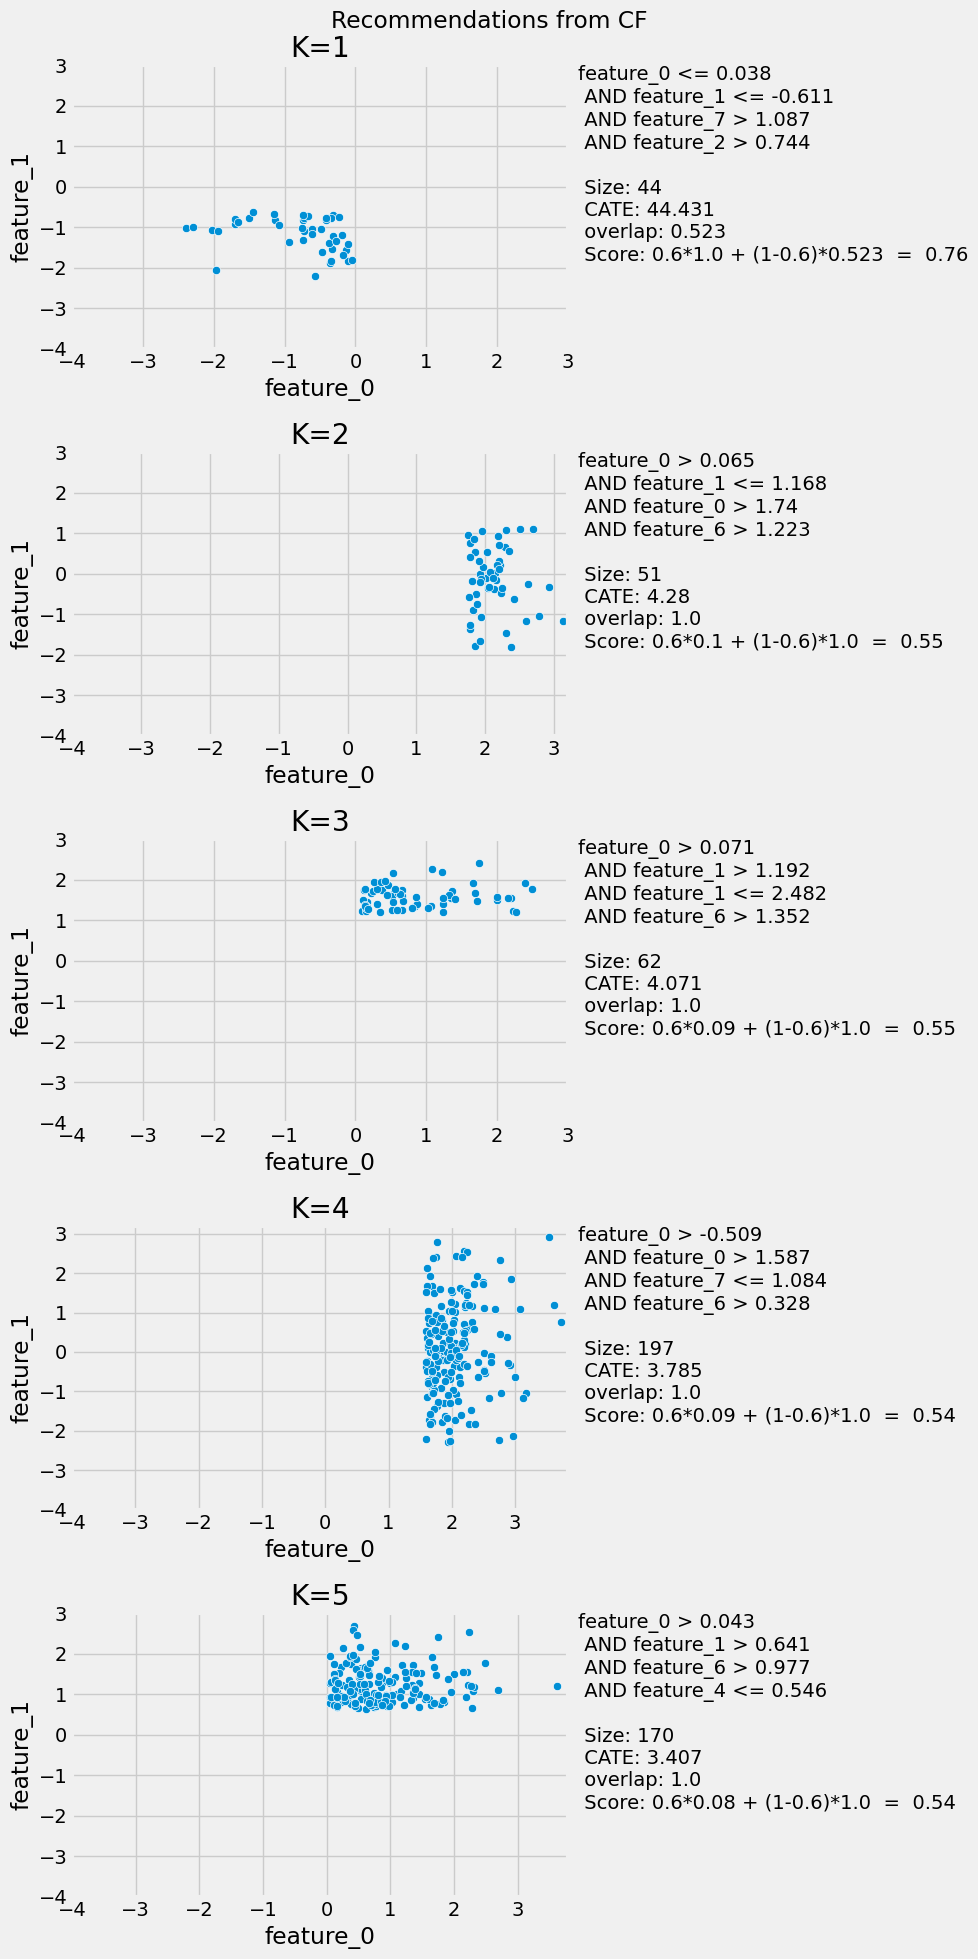

In [21]:
visualize_recommendations2(top_cf)

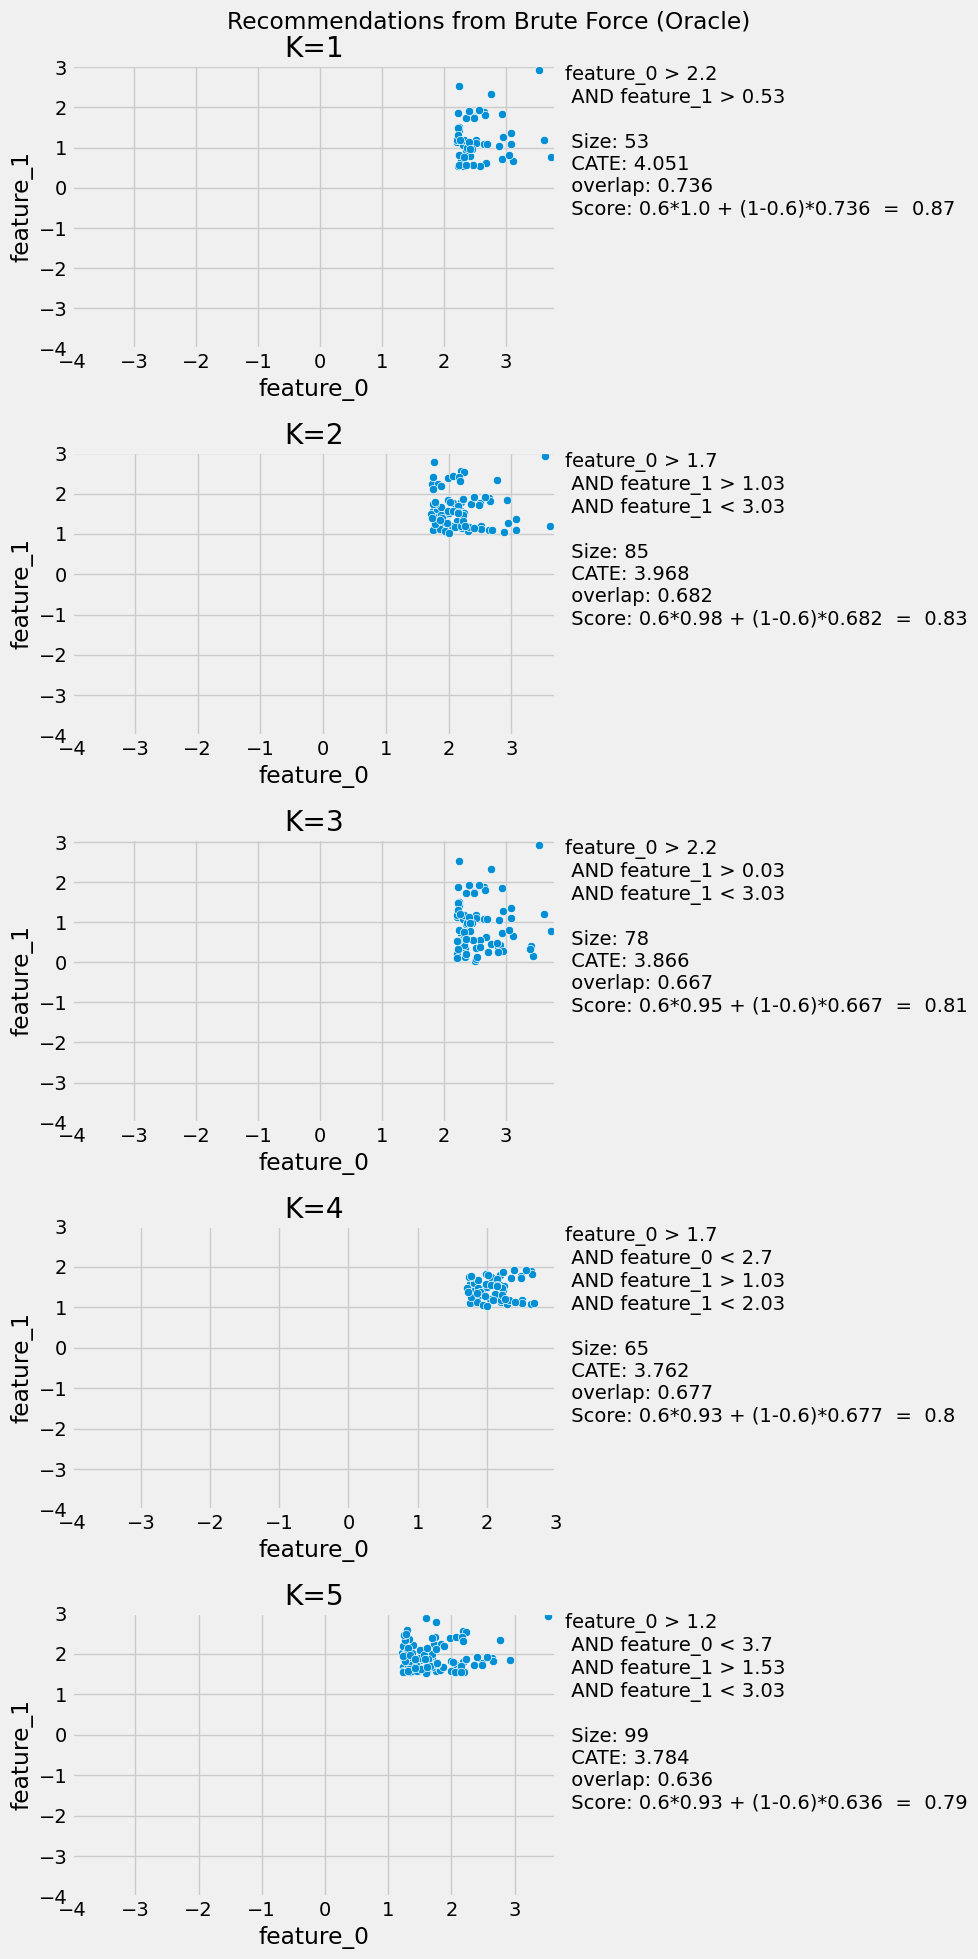

In [16]:
top_bf = scores[(scores['algorithm']=='Brute Force (Oracle)')]
visualize_recommendations2(top_bf)